# Gaussian Mixture Variance Landscape

Consider the two-component Gaussian mixture family
$$
P_\theta = \frac12\mathcal N(-0.25, \sigma_1^2) + \frac12\mathcal N(0.25, \sigma_2^2),
\qquad \theta=(\sigma_1,\sigma_2), \qquad \sigma_1,\sigma_2>0.
$$

The target is another two-component Gaussian mixture with the same component means and standard deviations $0.5$ and $3.0$:
$$
\mathbb Q = \frac12\mathcal N(-0.25, 0.5^2) + \frac12\mathcal N(0.25, 3.0^2).
$$

We plot the population RBF-MMD landscape with respect to the two standard deviations and overlay GD and PGD trajectories.

## GD and Projected GD

Standard GD descends on the closed-form population objective $\mathrm{MMD}^2_{\ell_\infty}(P_\theta,\mathbb Q)$.

For PGD, particles are generated componentwise as
$$
X = m_C + \sigma_C Z, \qquad C\in\{1,2\}, \qquad Z\sim\mathcal N(0,1),
$$
and the MMD particle descent direction is projected onto the tangent directions $Z\mathbf 1\{C=1\}$ and $Z\mathbf 1\{C=2\}$.

In [32]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

plt.rcParams['axes.grid'] = True
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.labelsize'] = 18
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath, amsfonts, mathrsfs, amssymb}')

# plt.rc('font', family='Arial', size=12)
plt.rc('axes', titlesize=32, labelsize=32, grid=True)
plt.rc('lines', linewidth=2)
plt.rc('legend', fontsize=32, frameon=False)
plt.rc('xtick', labelsize=26, direction='in')
plt.rc('ytick', labelsize=26, direction='in')
plt.rcParams['lines.markersize'] = 14
plt.rc('figure', figsize=(6, 4), dpi=100)

landscape_cmap = mcolors.LinearSegmentedColormap.from_list(
    'truncated_blues',
    plt.cm.Blues(np.linspace(0.2, 1.0, 256)),
)

component_means = np.array([-0.25, 0.25])
target_stds = np.array([0.5, 3.0])
component_weights = np.array([0.5, 0.5])

def gaussian_kernel_expectation(mean_gap, variance_sum, ell):
    denom = ell**2 + variance_sum
    return ell / np.sqrt(denom) * np.exp(-0.5 * mean_gap**2 / denom)

def mixture_kernel_expectation(means_a, stds_a, means_b, stds_b, ell, weights_a=None, weights_b=None):
    means_a = np.asarray(means_a, dtype=float)
    stds_a = np.asarray(stds_a, dtype=float)
    means_b = np.asarray(means_b, dtype=float)
    stds_b = np.asarray(stds_b, dtype=float)
    if weights_a is None:
        weights_a = np.full(means_a.shape, 1.0 / means_a.size)
    if weights_b is None:
        weights_b = np.full(means_b.shape, 1.0 / means_b.size)

    total = 0.0
    for i in range(means_a.size):
        for j in range(means_b.size):
            mean_gap = means_a[i] - means_b[j]
            variance_sum = stds_a[i] ** 2 + stds_b[j] ** 2
            total += weights_a[i] * weights_b[j] * gaussian_kernel_expectation(mean_gap, variance_sum, ell)
    return total

def mixture_mmd2(stds, ell):
    stds = np.maximum(np.asarray(stds, dtype=float), 1e-8)
    pp = mixture_kernel_expectation(component_means, stds, component_means, stds, ell, component_weights, component_weights)
    qq = mixture_kernel_expectation(component_means, target_stds, component_means, target_stds, ell, component_weights, component_weights)
    pq = mixture_kernel_expectation(component_means, stds, component_means, target_stds, ell, component_weights, component_weights)
    return pp + qq - 2.0 * pq

def mixture_mmd2_grid(sigma1_mesh, sigma2_mesh, ell):
    values = np.empty_like(sigma1_mesh, dtype=float)
    for index in np.ndindex(sigma1_mesh.shape):
        values[index] = mixture_mmd2([sigma1_mesh[index], sigma2_mesh[index]], ell)
    return values

def finite_difference_grad(theta, ell, eps=1e-4):
    theta = np.asarray(theta, dtype=float)
    grad = np.zeros_like(theta)
    for k in range(theta.size):
        direction = np.zeros_like(theta)
        direction[k] = eps
        grad[k] = (mixture_mmd2(theta + direction, ell) - mixture_mmd2(theta - direction, ell)) / (2.0 * eps)
    return grad

def finite_difference_hessian(theta, ell, eps=1e-4):
    theta = np.asarray(theta, dtype=float)
    hessian = np.zeros((theta.size, theta.size))
    for i in range(theta.size):
        for j in range(theta.size):
            ei = np.zeros_like(theta)
            ej = np.zeros_like(theta)
            ei[i] = eps
            ej[j] = eps
            hessian[i, j] = (
                mixture_mmd2(theta + ei + ej, ell)
                - mixture_mmd2(theta + ei - ej, ell)
                - mixture_mmd2(theta - ei + ej, ell)
                + mixture_mmd2(theta - ei - ej, ell)
            ) / (4.0 * eps**2)
    return hessian

def run_gd(theta0, ell, step_size, n_steps, sigma_floor=0.05):
    theta = np.asarray(theta0, dtype=float).copy()
    traj = [theta.copy()]
    hist = [mixture_mmd2(theta, ell)]
    for _ in range(n_steps):
        theta -= step_size * finite_difference_grad(theta, ell)
        theta = np.maximum(theta, sigma_floor)
        traj.append(theta.copy())
        hist.append(mixture_mmd2(theta, ell))
    return np.asarray(traj), np.asarray(hist)

def sample_mixture_particles(stds, n_particles, seed):
    rng = np.random.default_rng(seed)
    components = rng.choice(2, size=n_particles, p=component_weights)
    z = rng.normal(size=n_particles)
    x = component_means[components] + np.asarray(stds)[components] * z
    return x, components, z

def build_balanced_latent_particles(n_particles):
    if n_particles % 2 != 0:
        raise ValueError('n_particles must be even for the balanced two-component design.')
    n_per_component = n_particles // 2
    quantiles = (np.arange(n_per_component) + 0.5) / n_per_component
    z_one_component = norm.ppf(quantiles)
    components = np.repeat(np.arange(2), n_per_component)
    z = np.tile(z_one_component, 2)
    return components, z

def mmd_particle_gradient_to_target_mixture(x, ell):
    n = x.size
    diff_xx = x[:, None] - x[None, :]
    k_xx = np.exp(-0.5 * (diff_xx / ell) ** 2)
    grad_xx = -2.0 * np.sum(diff_xx * k_xx, axis=1) / (n * n * ell**2)

    grad_cross = np.zeros_like(x)
    for mean, std, weight in zip(component_means, target_stds, component_weights):
        denom = ell**2 + std**2
        expected_kernel = ell / np.sqrt(denom) * np.exp(-0.5 * (x - mean) ** 2 / denom)
        grad_cross += 2.0 * weight * (x - mean) * expected_kernel / (n * denom)
    return grad_xx + grad_cross

def run_pgd(theta0, base_components, base_z, ell_inf, ell0, decay, ridge, step_size, n_steps, sigma_floor=0.05):
    theta = np.asarray(theta0, dtype=float).copy()
    tangent = np.column_stack([
        np.where(base_components == 0, base_z, 0.0),
        np.where(base_components == 1, base_z, 0.0),
    ])
    gram = tangent.T @ tangent / tangent.shape[0] + ridge * np.eye(2)

    traj = [theta.copy()]
    hist = [mixture_mmd2(theta, ell_inf)]
    ell_hist = []
    for t in range(n_steps):
        ell_t = max(ell_inf, ell0 * decay**t)
        x = component_means[base_components] + theta[base_components] * base_z
        force = -mmd_particle_gradient_to_target_mixture(x, ell_t)
        rhs = tangent.T @ force / tangent.shape[0]
        delta = np.linalg.solve(gram, rhs)
        theta += step_size * delta
        theta = np.maximum(theta, sigma_floor)
        traj.append(theta.copy())
        hist.append(mixture_mmd2(theta, ell_inf))
        ell_hist.append(ell_t)
    return np.asarray(traj), np.asarray(hist), np.asarray(ell_hist)


In [33]:
ell_inf = 1.0
ell0 = 5.0
decay = 0.99
ridge = 1e-3
n_steps = 650

theta0 = np.array([4.0, 3.5])
gd_step = 5.0
pgd_step = 1000.0

sigma1_grid = np.linspace(0.15, 4.5, 201)
sigma2_grid = np.linspace(0.15, 3.7, 211)
sigma1_mesh, sigma2_mesh = np.meshgrid(sigma1_grid, sigma2_grid)
landscape_lengthscales = np.array([0.2, 1.0, 5.0, 10.0])
computed_landscape_lengthscales = np.unique(np.append(landscape_lengthscales, ell_inf))
lengthscale_landscapes = {
    float(ell): mixture_mmd2_grid(sigma1_mesh, sigma2_mesh, ell)
    for ell in computed_landscape_lengthscales
}
landscape_values = lengthscale_landscapes[float(ell_inf)]
lengthscale_global_optima = {}
for ell, values in lengthscale_landscapes.items():
    ell_minimum_index = np.unravel_index(np.argmin(values), values.shape)
    lengthscale_global_optima[float(ell)] = {
        'theta': np.array([sigma1_mesh[ell_minimum_index], sigma2_mesh[ell_minimum_index]]),
        'value': float(values[ell_minimum_index]),
    }

n_particles = 512
base_components, base_z = build_balanced_latent_particles(n_particles)
gd_traj, gd_hist = run_gd(theta0, ell_inf, gd_step, n_steps)
pgd_traj, pgd_hist, ell_hist = run_pgd(
    theta0,
    base_components,
    base_z,
    ell_inf=ell_inf,
    ell0=ell0,
    decay=decay,
    ridge=ridge,
    step_size=pgd_step,
    n_steps=n_steps,
)

minimum_index = np.unravel_index(np.argmin(landscape_values), landscape_values.shape)
grid_minimum = np.array([sigma1_mesh[minimum_index], sigma2_mesh[minimum_index]])
non_global_stationary = np.array([2.48168608, 0.77553404])
stationary_grad_norm = np.linalg.norm(finite_difference_grad(non_global_stationary, ell_inf))
stationary_hessian_eigs = np.linalg.eigvalsh(finite_difference_hessian(non_global_stationary, ell_inf))

print('Two-component Gaussian mixture variance landscape')
print('  P_theta = 0.5 N(-0.25, sigma_1^2) + 0.5 N(0.25, sigma_2^2)')
print('  Q       = 0.5 N(-0.25, 0.5^2)     + 0.5 N(0.25, 3.0^2)')
print(f'  theta0 = ({theta0[0]:.3f}, {theta0[1]:.3f})')
print(f'  ell_inf = {ell_inf:.2f}, ell0 = {ell0:.2f}, decay = {decay:.3f}')
print(f'  grid minimum = ({grid_minimum[0]:.4f}, {grid_minimum[1]:.4f})')
print(f'  non-global stationary point = ({non_global_stationary[0]:.4f}, {non_global_stationary[1]:.4f})')
print(f'    MMD^2 = {mixture_mmd2(non_global_stationary, ell_inf):.6e}, |grad| = {stationary_grad_norm:.2e}')
print(f'    Hessian eigenvalues = ({stationary_hessian_eigs[0]:.4e}, {stationary_hessian_eigs[1]:.4e})')
print(f'  GD final theta = ({gd_traj[-1, 0]:.4f}, {gd_traj[-1, 1]:.4f}), MMD^2 = {gd_hist[-1]:.6e}')
print(f'  PGD final theta = ({pgd_traj[-1, 0]:.4f}, {pgd_traj[-1, 1]:.4f}), MMD^2 = {pgd_hist[-1]:.6e}')
print(f'  MMD^2 at target = {mixture_mmd2(target_stds, ell_inf):.6e}')


Two-component Gaussian mixture variance landscape
  P_theta = 0.5 N(-0.25, sigma_1^2) + 0.5 N(0.25, sigma_2^2)
  Q       = 0.5 N(-0.25, 0.5^2)     + 0.5 N(0.25, 3.0^2)
  theta0 = (4.000, 3.500)
  ell_inf = 1.00, ell0 = 5.00, decay = 0.990
  grid minimum = (0.4980, 3.0069)
  non-global stationary point = (2.4817, 0.7755)
    MMD^2 = 2.516562e-02, |grad| = 7.93e-10
    Hessian eigenvalues = (6.7457e-03, 1.2215e-01)
  GD final theta = (2.4817, 0.7755), MMD^2 = 2.516562e-02
  PGD final theta = (0.5002, 3.0000), MMD^2 = 2.191200e-09
  MMD^2 at target = 0.000000e+00


/tmp/ipykernel_247871/2111121924.py:108: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax_history.set_ylim(bottom=0.0)


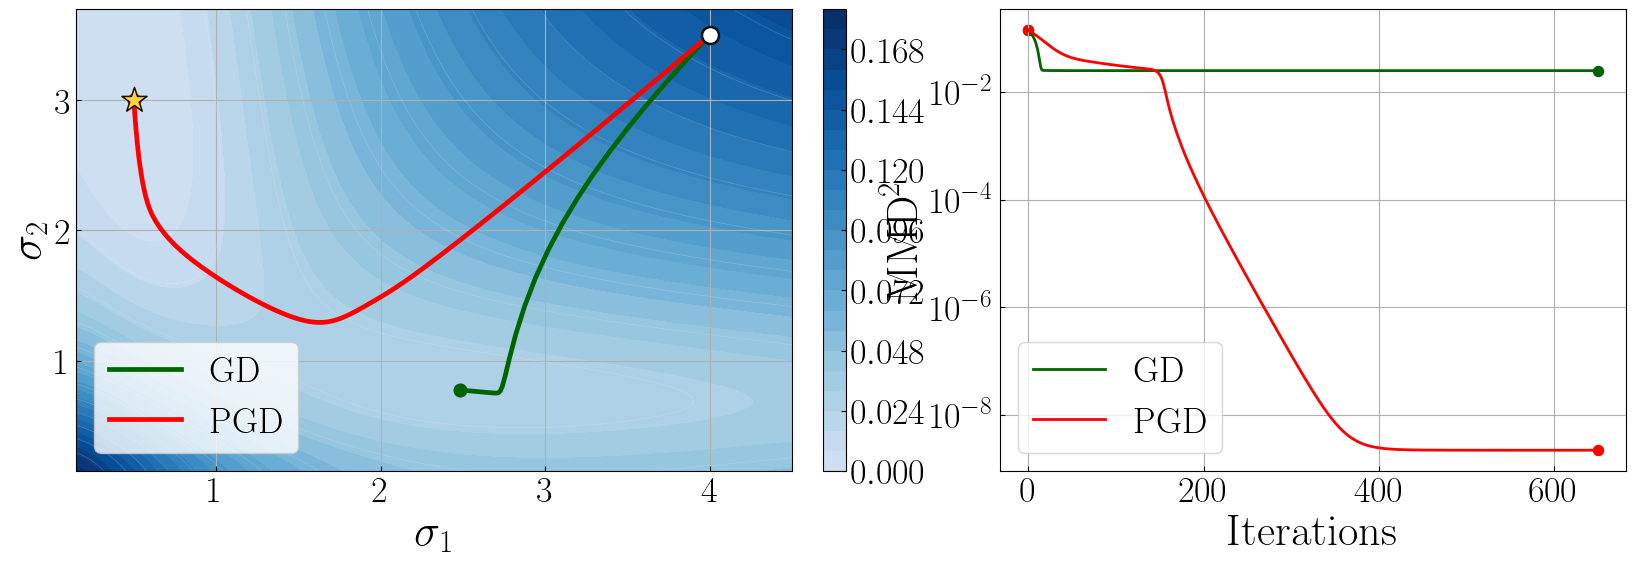

In [ ]:
figure_size = (20, 6)
axis_label_fontsize = 32
tick_label_fontsize = 26
legend_fontsize = 26
title_fontsize = 32
colorbar_label_fontsize = 32

global_optimum_theta = target_stds

fig, (ax_landscape, ax_history) = plt.subplots(
    1,
    2,
    figsize=figure_size,
    dpi=100,
    gridspec_kw={'width_ratios': [1.25, 1.0], 'wspace': 0.40},
)

contours = ax_landscape.contourf(
    sigma1_mesh,
    sigma2_mesh,
    landscape_values,
    levels=26,
    cmap=landscape_cmap,
    vmin=float(np.min(landscape_values)),
    vmax=float(np.max(landscape_values)),
)
ax_landscape.contour(
    sigma1_mesh,
    sigma2_mesh,
    landscape_values,
    levels=12,
    colors='#F8F9FA',
    linewidths=0.45,
    alpha=0.22,
)
ax_landscape.plot(gd_traj[:, 0], gd_traj[:, 1], color='darkgreen', lw=3.4, label='GD')
ax_landscape.plot(pgd_traj[:, 0], pgd_traj[:, 1], color='red', lw=3.4, label='PGD')
ax_landscape.scatter(
    [theta0[0]],
    [theta0[1]],
    marker='o',
    color='white',
    edgecolors='#111111',
    linewidths=1.8,
    zorder=7,
    s=150,
    # label=r'$\theta_0$',
)
ax_landscape.scatter(
    [global_optimum_theta[0]],
    [global_optimum_theta[1]],
    marker='*',
    color='#FFD43B',
    edgecolors='#111111',
    linewidths=1.1,
    zorder=8,
    s=360,
    # label=r'Global min.',
)
# ax_landscape.scatter(
#     [non_global_stationary[0]],
#     [non_global_stationary[1]],
#     marker='D',
#     color='#9B2226',
#     edgecolors='white',
#     linewidths=1.1,
#     zorder=8,
#     s=130,
#     label='Local min.',
# )
# ax_landscape.annotate(
#     r'$\theta_0$',
#     xy=(float(theta0[0]), float(theta0[1])),
#     xytext=(float(theta0[0]) + 0.16, float(theta0[1]) + 0.18),
#     color='#111111',
#     fontsize=24,
#     arrowprops=dict(arrowstyle='->', color='#111111', lw=1.3),
# )
# ax_landscape.annotate(
#     r'$\theta_\star$',
#     xy=(global_optimum_theta[0], global_optimum_theta[1]),
#     xytext=(global_optimum_theta[0] + 0.14, global_optimum_theta[1] + 0.16),
#     color='#111111',
#     fontsize=24,
#     arrowprops=dict(arrowstyle='->', color='#111111', lw=1.3),
# )
ax_landscape.scatter([gd_traj[-1, 0]], [gd_traj[-1, 1]], color='darkgreen', zorder=6, s=84)
ax_landscape.scatter([pgd_traj[-1, 0]], [pgd_traj[-1, 1]], color='red', zorder=6, s=84)
ax_landscape.set_xlim(sigma1_grid[0], sigma1_grid[-1])
ax_landscape.set_ylim(sigma2_grid[0], sigma2_grid[-1])
ax_landscape.set_xlabel(r'$\sigma_1$', fontsize=axis_label_fontsize)
ax_landscape.set_ylabel(r'$\sigma_2$', fontsize=axis_label_fontsize)
ax_landscape.tick_params(axis='both', labelsize=tick_label_fontsize)
ax_landscape.legend(loc='best', fontsize=legend_fontsize, frameon=True)
colorbar = fig.colorbar(contours, ax=ax_landscape, fraction=0.046, pad=0.04)
colorbar.ax.tick_params(labelsize=tick_label_fontsize)

steps = np.arange(n_steps + 1)
objective_gd = gd_hist
objective_pgd = pgd_hist
ax_history.plot(steps, objective_gd, color='darkgreen', label='GD')
ax_history.plot(steps, objective_pgd, color='red', label='PGD')
ax_history.scatter([0, n_steps], [objective_gd[0], objective_gd[-1]], color='darkgreen', s=52)
ax_history.scatter([0, n_steps], [objective_pgd[0], objective_pgd[-1]], color='red', s=52)
ax_history.set_xlabel('Iterations', fontsize=axis_label_fontsize)
ax_history.set_ylabel(r'$\mathrm{MMD}^2$', fontsize=axis_label_fontsize)
ax_history.set_yscale('log')
ax_history.set_ylim(bottom=0.0)
ax_history.tick_params(axis='both', labelsize=tick_label_fontsize)
ax_history.legend(loc='best', fontsize=legend_fontsize, frameon=True)

plt.savefig('./figures/mmd_nonconvex_mean_cov_gaussian.pdf', bbox_inches='tight')
plt.show()


In [ ]:
positive_lengthscale_values = [
    values[values > 0]
    for values in lengthscale_landscapes.values()
    if np.any(values > 0)
]
lengthscale_positive_floor = min(float(np.min(values)) for values in positive_lengthscale_values)
lengthscale_vmin = lengthscale_positive_floor
lengthscale_vmax = max(float(np.max(values)) for values in lengthscale_landscapes.values())
lengthscale_levels = np.geomspace(lengthscale_vmin, lengthscale_vmax, 24)
lengthscale_contour_levels = np.geomspace(lengthscale_vmin, lengthscale_vmax, 10)
lengthscale_norm = mcolors.LogNorm(vmin=lengthscale_vmin, vmax=lengthscale_vmax)

fig, ax_lengthscales = plt.subplots(1, 4, figsize=(16, 3), dpi=100)
ax_lengthscales = ax_lengthscales.ravel()

for ax, ell in zip(ax_lengthscales, landscape_lengthscales):
    values = np.maximum(lengthscale_landscapes[float(ell)], lengthscale_positive_floor)
    contours = ax.contourf(
        sigma1_mesh,
        sigma2_mesh,
        values,
        levels=lengthscale_levels,
        cmap=landscape_cmap,
        norm=lengthscale_norm,
    )
    ax.contour(
        sigma1_mesh,
        sigma2_mesh,
        values,
        levels=lengthscale_contour_levels,
        colors='#F8F9FA',
        linewidths=0.35,
        alpha=0.22,
        norm=lengthscale_norm,
    )
    optimum_theta = lengthscale_global_optima[float(ell)]['theta']
    ax.scatter(
        [optimum_theta[0]],
        [optimum_theta[1]],
        marker='*',
        color='#FFD43B',
        edgecolors='#111111',
        linewidths=1.0,
        zorder=8,
        s=260,
    )
    ax.set_title(r'$\ell = ' + f'{ell:.1f}' + r'$', fontsize=title_fontsize, pad=8)
    ax.set_xlim(sigma1_grid[0], sigma1_grid[-1])
    ax.set_ylim(sigma2_grid[0], sigma2_grid[-1])
    ax.tick_params(axis='both', labelsize=tick_label_fontsize)

for ax in ax_lengthscales[1:]:
    ax.set_yticklabels([])
for ax in ax_lengthscales:
    ax.set_xlabel(r'$\sigma_1$', fontsize=axis_label_fontsize)
ax_lengthscales[0].set_ylabel(r'$\sigma_2$', fontsize=axis_label_fontsize)

colorbar = fig.colorbar(contours, ax=ax_lengthscales.tolist(), fraction=0.046, pad=0.04)
colorbar.ax.tick_params(labelsize=tick_label_fontsize)
colorbar.set_label(r'$\mathrm{MMD}^2$ (Log)', fontsize=colorbar_label_fontsize)

plt.savefig('./figures/mmd_nonconvex_mean_cov_gaussian_lengthscales_log.pdf', bbox_inches='tight')
plt.show()


## Interpretation

The landscape coordinates are the two component standard deviations of $P_\theta$. In this design the component means are closer, $\pm 0.25$, and the target scales are more separated, $(0.5,3.0)$. This creates an additional stationary point near $(2.48,0.78)$ that is not a global minimizer; the finite-difference Hessian is positive there, so it is a local minimum of the population MMD landscape.

Both methods are initialized farther away at $(4.0,3.5)$. Fixed-scale GD descends into the bad local basin, while PGD starts from a smoother lengthscale and anneals to $\ell_\infty=1$, which lets its projected particle trajectory move into the global basin. The PGD particles use balanced Gaussian quantiles rather than Monte Carlo draws so the trajectory reflects the population geometry rather than sampling noise.
